In [166]:
library(pracma)
library(glmnet)
library(ggplot2)
library(stats)
library(partykit)
source("Utils.R")
library(gridExtra)
library(MASS)

In [3]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

Veamos qué pasa con los intervalos de confianza obtenidos mediante boostraping

In [5]:
setSeed()
N <- 500
n <- nrow(TRAIN_X)
lambdas <- data.frame()
for(i in 1:N){
    indices <- sample(1:n, n, replace=TRUE)
    X <- TRAIN_X[indices, ]
    X <- scale(X)
    lambdas <- rbind(lambdas, eigen(cov(X))$values)
    message(progreso(i, 1:N))
}
colnames(lambdas) <- paste('λ', 1:301, sep="")

El progreso es del 0.2 %

El progreso es del 0.4 %

El progreso es del 0.6 %

El progreso es del 0.8 %

El progreso es del 1 %

El progreso es del 1.2 %

El progreso es del 1.4 %

El progreso es del 1.6 %

El progreso es del 1.8 %

El progreso es del 2 %

El progreso es del 2.2 %

El progreso es del 2.4 %

El progreso es del 2.6 %

El progreso es del 2.8 %

El progreso es del 3 %

El progreso es del 3.2 %

El progreso es del 3.4 %

El progreso es del 3.6 %

El progreso es del 3.8 %

El progreso es del 4 %

El progreso es del 4.2 %

El progreso es del 4.4 %

El progreso es del 4.6 %

El progreso es del 4.8 %

El progreso es del 5 %

El progreso es del 5.2 %

El progreso es del 5.4 %

El progreso es del 5.6 %

El progreso es del 5.8 %

El progreso es del 6 %

El progreso es del 6.2 %

El progreso es del 6.4 %

El progreso es del 6.6 %

El progreso es del 6.8 %

El progreso es del 7 %

El progreso es del 7.2 %

El progreso es del 7.4 %

El progreso es del 7.6 %

El progreso es del 7.8 %



El progreso es del 62.2 %

El progreso es del 62.4 %

El progreso es del 62.6 %

El progreso es del 62.8 %

El progreso es del 63 %

El progreso es del 63.2 %

El progreso es del 63.4 %

El progreso es del 63.6 %

El progreso es del 63.8 %

El progreso es del 64 %

El progreso es del 64.2 %

El progreso es del 64.4 %

El progreso es del 64.6 %

El progreso es del 64.8 %

El progreso es del 65 %

El progreso es del 65.2 %

El progreso es del 65.4 %

El progreso es del 65.6 %

El progreso es del 65.8 %

El progreso es del 66 %

El progreso es del 66.2 %

El progreso es del 66.4 %

El progreso es del 66.6 %

El progreso es del 66.8 %

El progreso es del 67 %

El progreso es del 67.2 %

El progreso es del 67.4 %

El progreso es del 67.6 %

El progreso es del 67.8 %

El progreso es del 68 %

El progreso es del 68.2 %

El progreso es del 68.4 %

El progreso es del 68.6 %

El progreso es del 68.8 %

El progreso es del 69 %

El progreso es del 69.2 %

El progreso es del 69.4 %

El progreso es 

In [6]:
limlambda = 1:10
summary_lambdas <- function(l){
    c(           quantile(l, 0.025),
      "Mean"   = mean(l),
      "Median" = median(l),
                 quantile(l, 0.975))
}


lambda_summary=as.data.frame(t(apply(lambdas[, limlambda], 2, summary_lambdas)))
lambda_summary$Lambda = limlambda
colnames(lambda_summary) <- c("q025", "Mean", "Median", "q975", "Lambda")

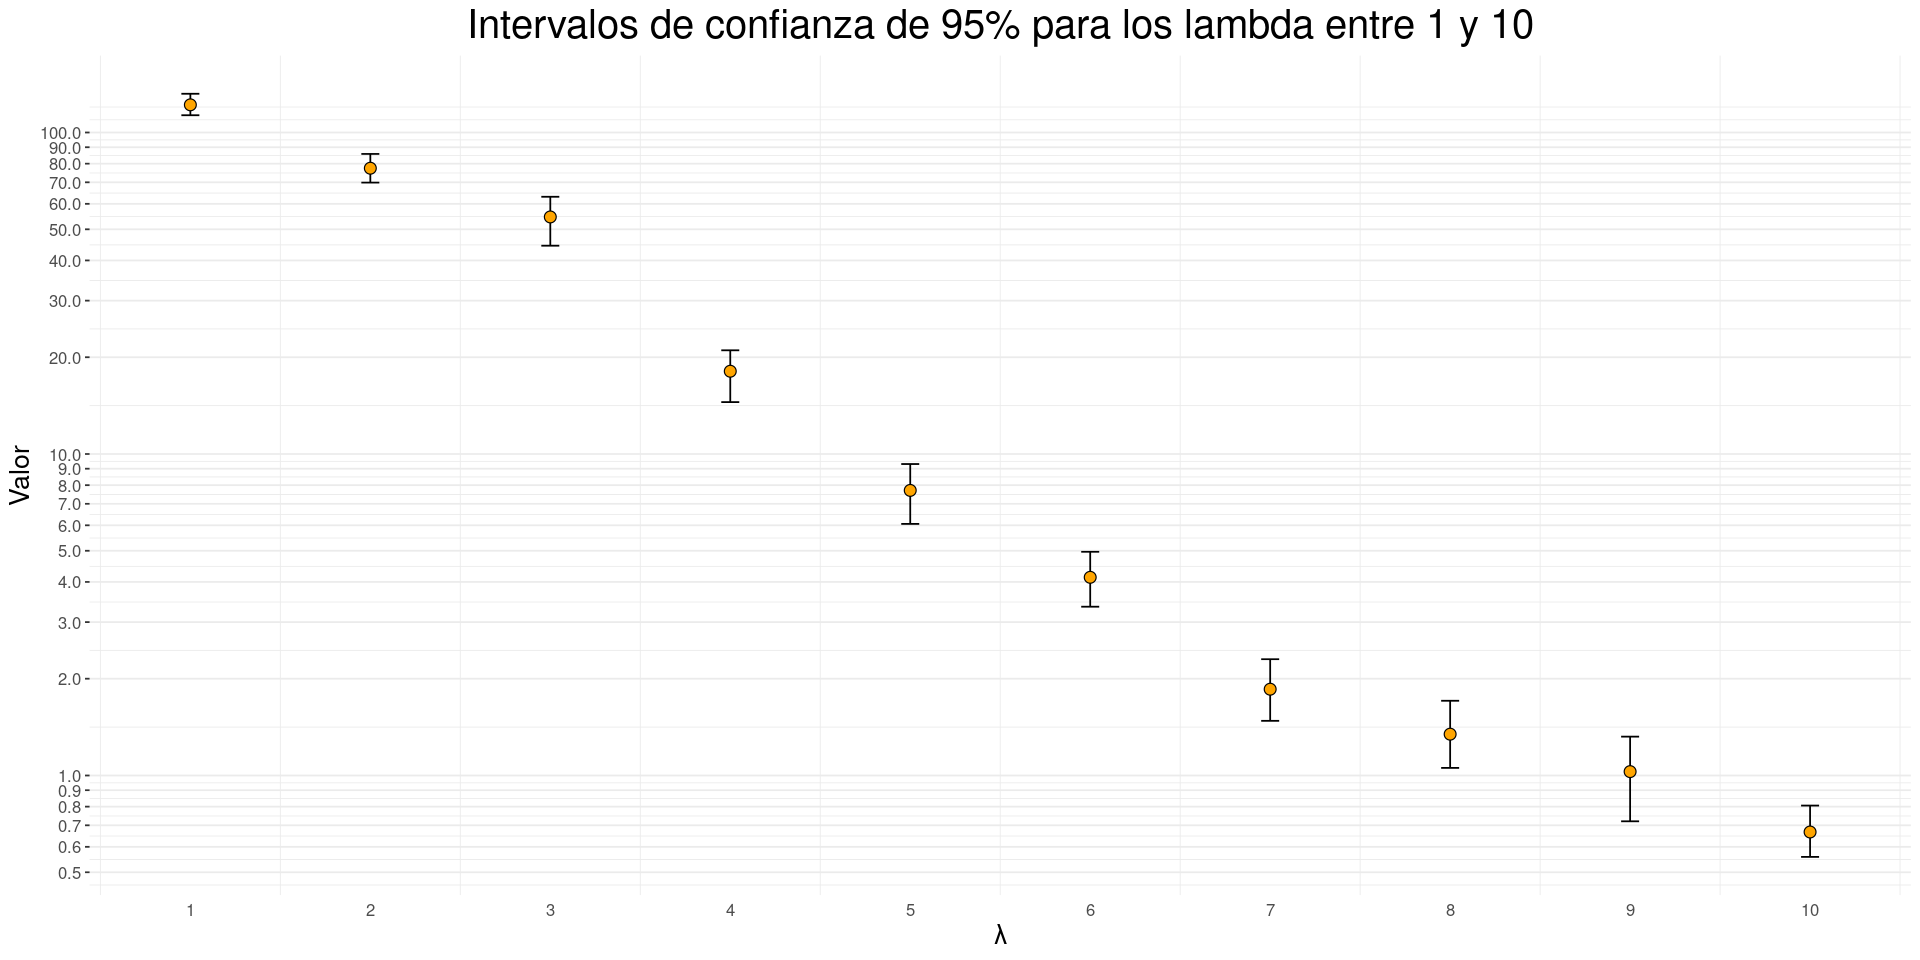

In [7]:
pd <- position_dodge(width = 0.2)
options(repr.plot.width=16, repr.plot.height=8)
ggplot(lambda_summary, aes(x=Lambda, y=Mean)) + 
    geom_errorbar(aes(ymin=q025, ymax=q975), colour="black", width=.1, position=pd) +
    geom_point(position=pd, size=3, shape=21, fill="orange") +
    xlab("λ") +
    ylab("Valor") +
    ggtitle("Intervalos de confianza de 95% para los lambda entre 1 y 10") +
    scale_y_continuous(breaks=c(seq(0.1,0.9,0.1), seq(1,9,1), seq(10, 90, 10), seq(100,900,100)), trans='log10') +
    scale_x_continuous(breaks=limlambda) +
    theme_bw() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=10),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank())

In [8]:
summary_lambdas <- function(l){
    c(           quantile(l, 0.01),
      "Mean"   = mean(l),
      "Median" = median(l),
                 quantile(l, 0.99))
}

lambdas2 <- t(lambdas)
lambdas2 <- apply(lambdas2, 2, function(l) (100*cumsum(l)/sum(l)))[limlambda, ]
lambdas2 <- as.data.frame(t(apply(lambdas2, 1, summary_lambdas)))
lambdas2$Lambda <- limlambda
colnames(lambdas2) <- c("q001", "Mean", "Median", "q099", "Lambda")

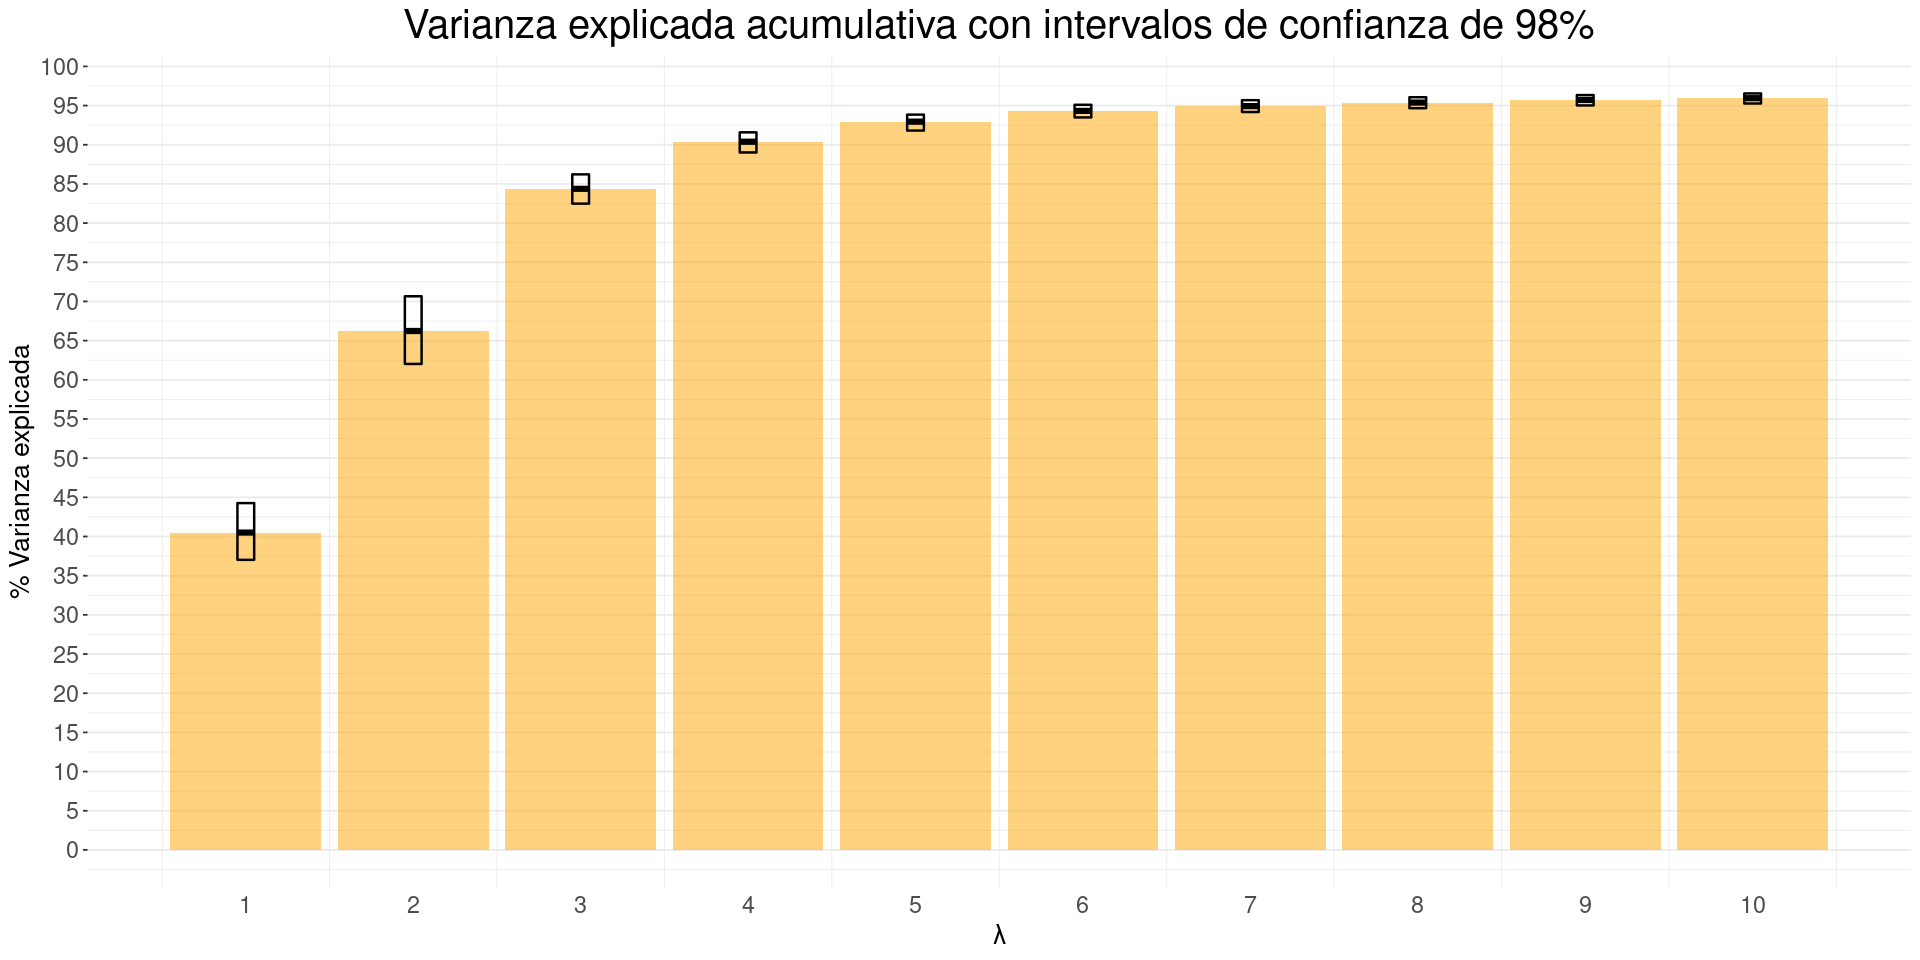

In [9]:
options(repr.plot.width=16, repr.plot.height=8)
ggplot(lambdas2) +
  geom_bar(aes(x=Lambda, y=Mean), stat="identity", fill="orange", alpha=0.5) +
  geom_crossbar(aes(x=Lambda, y=Mean, ymin=q001, ymax=q099), width=0.1, colour="black", alpha=1, size=0.7) +
  xlab("λ") +
  ylab("% Varianza explicada") +
  ggtitle("Varianza explicada acumulativa con intervalos de confianza de 98%") +
  scale_y_continuous(breaks=seq(0, 100, 5)) +
  scale_x_continuous(breaks=limlambda) +
  theme_bw() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank())

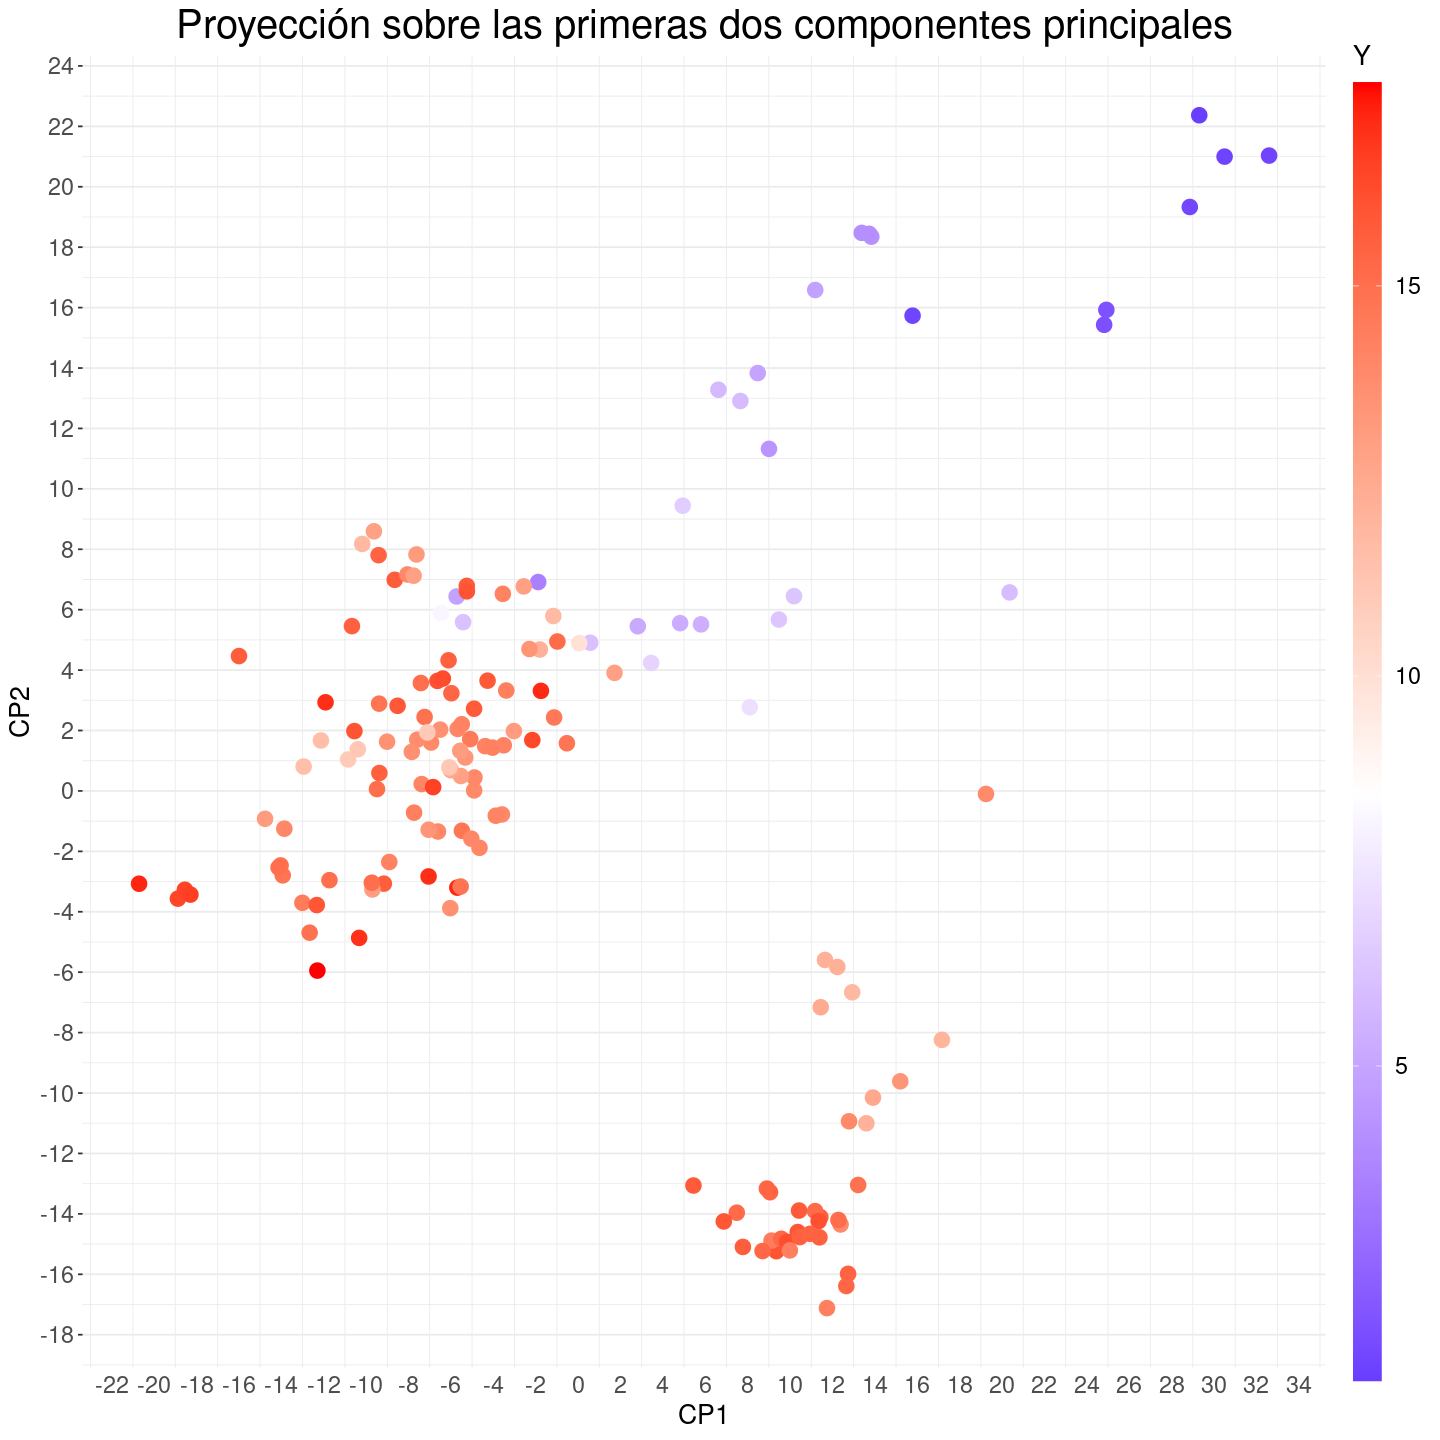

In [10]:
x <- scale(TRAIN_X)
s<-cov(x)
e<-eigen(s)
gamma<-e$vectors
lambda<-e$values
xraya<-apply(x,2,mean)
v<-t(gamma)%*%(t(x)-xraya)

mid<-mean(TRAIN_Y)

options(repr.plot.width=12, repr.plot.height=12)
ggplot() +
    geom_point(aes(x=v[1,], y=v[2,], color=TRAIN_Y), size=4) + 
    scale_color_gradient2(midpoint=8.5, low="blue", mid="white", high="red") +
    xlab("CP1") + ylab("CP2") + labs(color="Y") +
    ggtitle("Proyección sobre las primeras dos componentes principales") +
    scale_y_continuous(breaks=seq(-20, 30, 2)) +
    scale_x_continuous(breaks=seq(-30, 40, 2)) +
    theme_bw() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.key.height = unit(5.5, 'cm'),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14))

In [11]:
PCA_X <- as.data.frame(t(v)[, 1:6])
PCA_DF <- PCA_X
PCA_DF$Y <- TRAIN_Y

In [12]:
get_CP_plot <- function(pca, i, j){
    options(repr.plot.width=12, repr.plot.height=12)
    p <- ggplot() +
        geom_point(aes(x=pca[,i], y=pca[,j], color=TRAIN_Y), size=0.3) + 
        scale_color_gradient2(midpoint=8.5, low="blue", mid="white", high="red") +
        xlab(paste("CP", i, sep="")) + ylab(paste("CP", j, sep="")) + labs(color="Y") +
        theme_bw() +
        theme(plot.title = element_blank(),
            axis.text=element_text(size=8),
            axis.title=element_text(size=10),
            panel.grid.major.x = element_blank(),
            panel.border = element_blank(),
            axis.ticks.x = element_blank(),
            legend.position = "none")
    return(p)
}

get_Dist_plot <- function(pca, i){
    p <- ggplot() + geom_density(aes(x=pca[,i])) + theme_bw() + xlab(paste("CP", i, sep="")) +
            theme(panel.grid.major.x = element_blank(),
                  panel.border = element_blank())
    return(p)
}

get_Cor_plot <- function(pca, i, j){
    corr <- round(cor(pca)[i, j], 3)
    p <- ggplot() + 
      annotate("text", x = 4, y = 25, size=8, label = paste("cor =", corr)) + 
      theme_void()
    return(p)
}

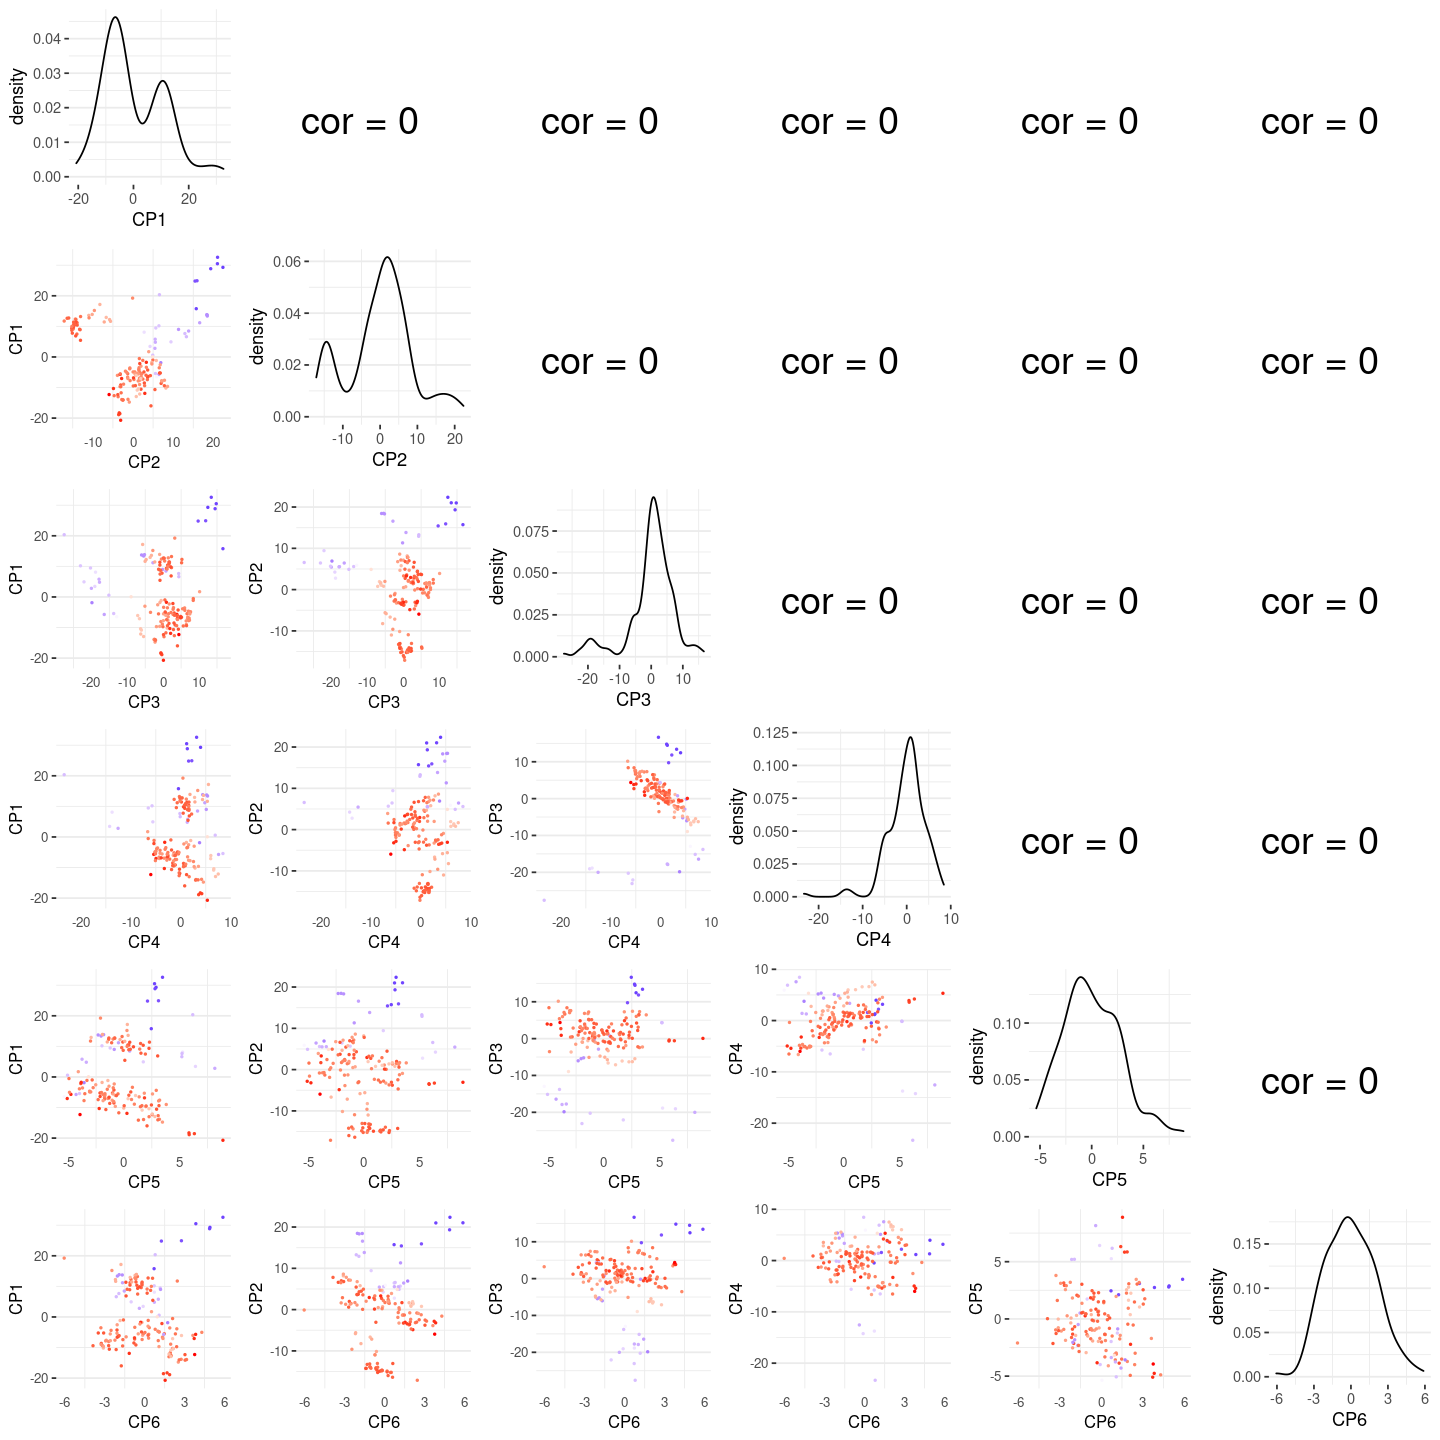

In [13]:
plots <- list()
for(i in 1:6){
    for(j in 1:6){
        k = (i-1)*6+j
        if(i > j){
            plots[[k]] <- get_CP_plot(PCA_DF, i, j)
        }else if(i==j){
            plots[[k]] <- get_Dist_plot(PCA_DF, i)
        }else{
            plots[[k]] <- get_Cor_plot(PCA_DF, i, j)
        }
    }
}
do.call(grid.arrange, plots)

# Entrenamiento

### Regresión lineal

In [164]:
model <- lm(Y~., data=PCA_DF)

In [50]:
a <- summary(model)

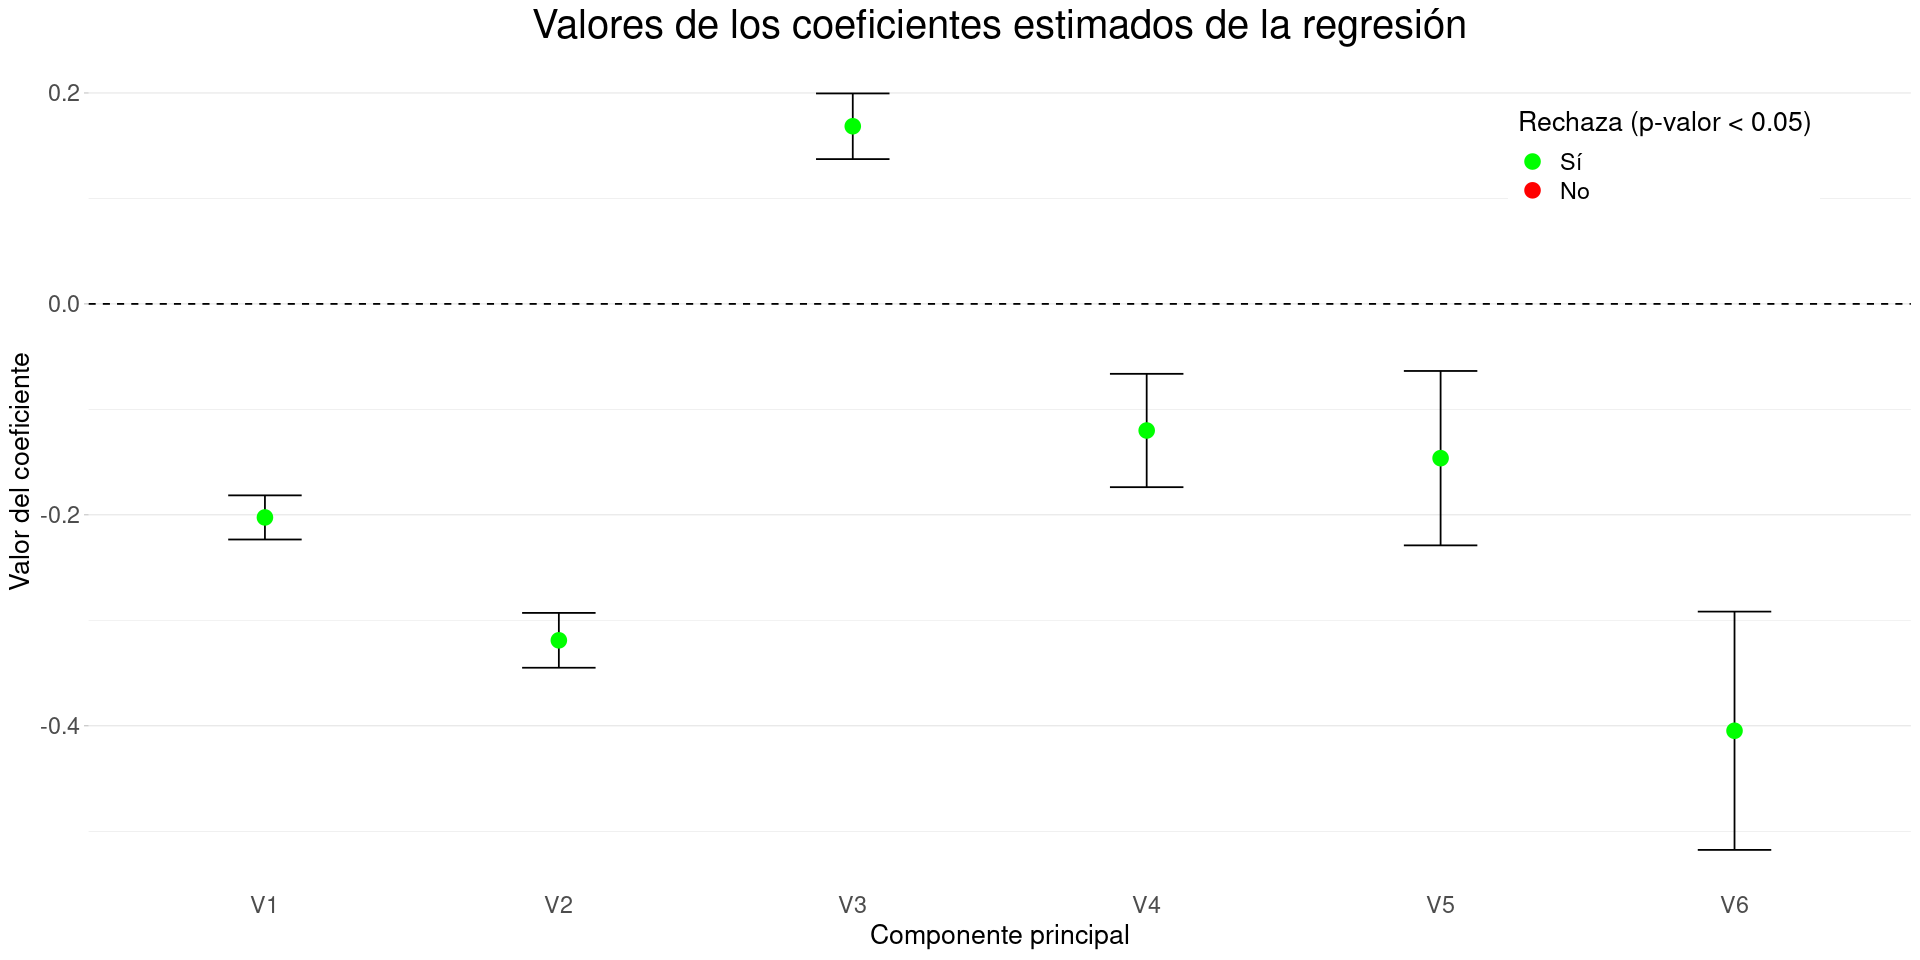

In [75]:
data_plot <- data.frame(
    x=colnames(PCA_X),
    y=a$coefficients[-1, 1],
    sd=a$coefficients[-1, 2],
    col=(a$coefficients[-1, 4] < 0.05)
)
colnames(data_plot) <- c("V", "Estimate", "SD", "Rechaza")

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x = V, y = Estimate)) + 
  ggtitle("Valores de los coeficientes estimados de la regresión") +
  geom_errorbar(aes(ymin = Estimate - 2*SD, ymax = Estimate + 2*SD),  width=0.25) +
  geom_point(aes(color = Rechaza), size = 4) + 
  theme_light() +
  scale_colour_manual(values = c("TRUE" = "green", "FALSE" = "red"),
                      labels = c("Sí", "No"), breaks = c("TRUE", "FALSE")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  geom_hline(yintercept=0, linetype="dashed") + 
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  xlab("Componente principal") + ylab("Valor del coeficiente")

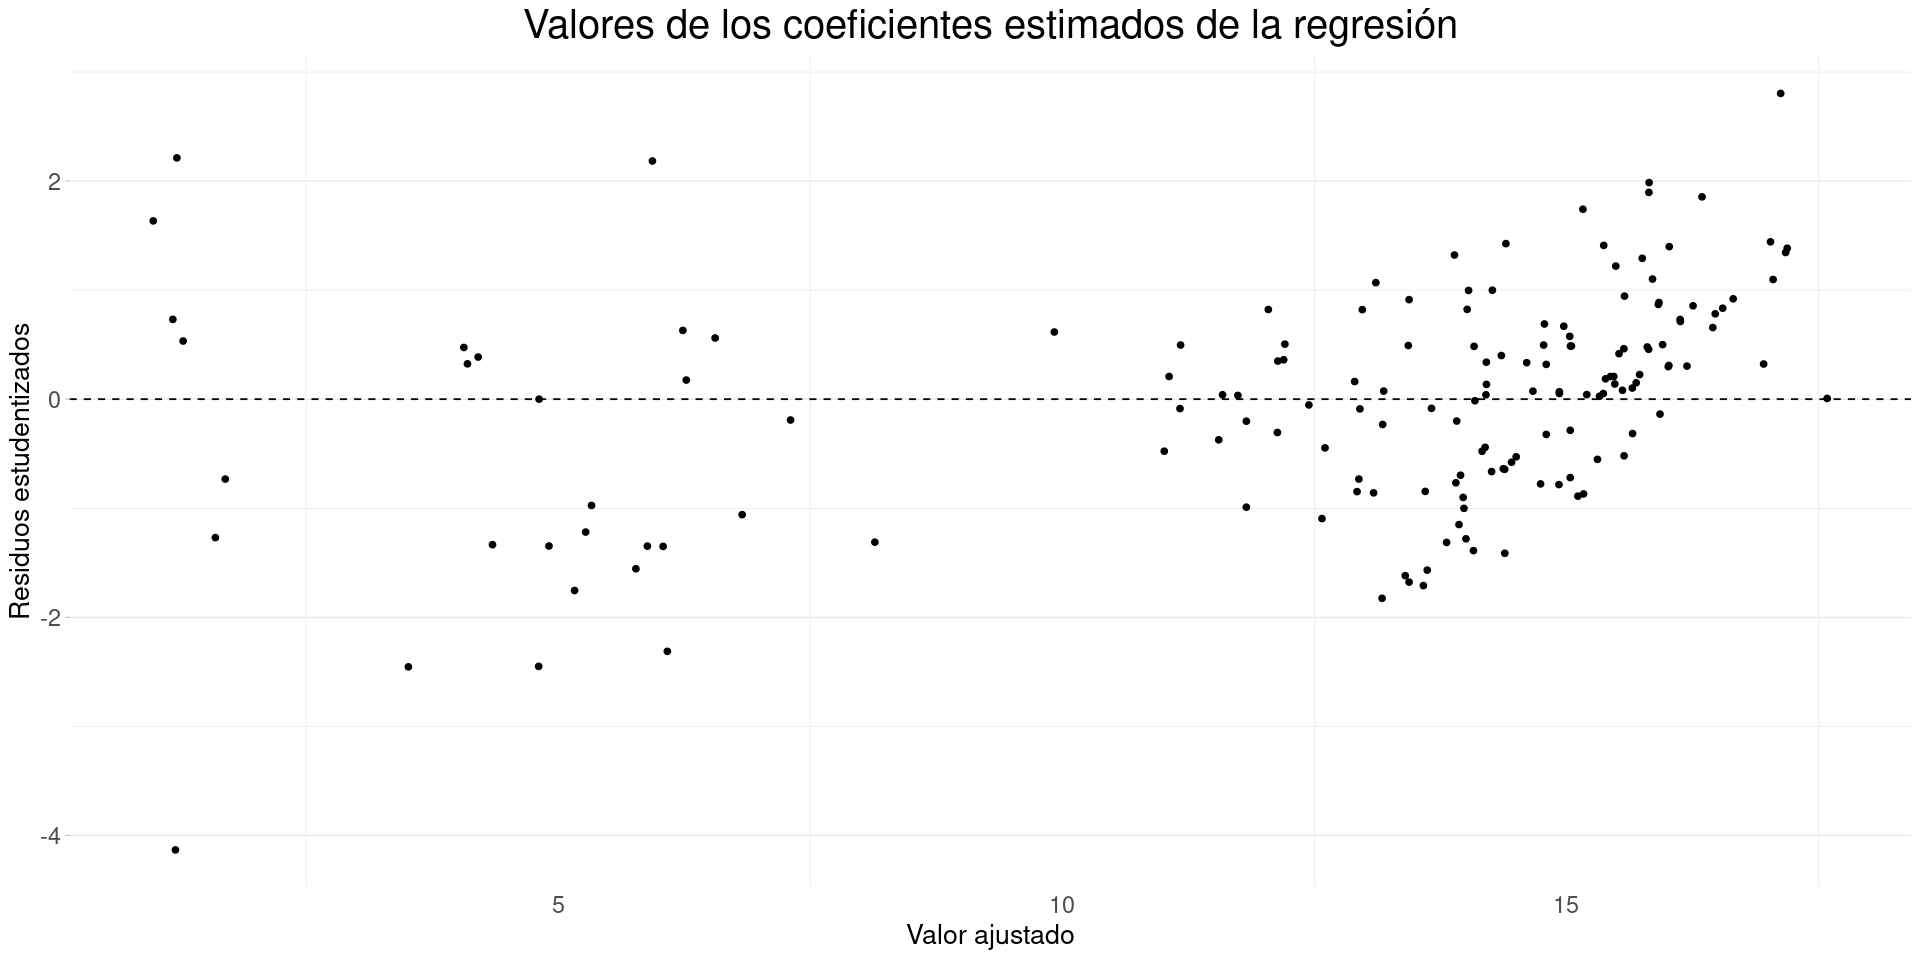

In [172]:
b <- data.frame(
    "y" = PCA_DF$Y,
    "tmenosi" = studres(model)
)
options(repr.plot.width=16, repr.plot.height=8)
ggplot(b, aes(x=y, y=tmenosi)) +
    ggtitle("Valores de los coeficientes estimados de la regresión") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    geom_hline(yintercept=0, linetype="dashed") + 
    xlab("Valor ajustado") + ylab("Residuos estudentizados")

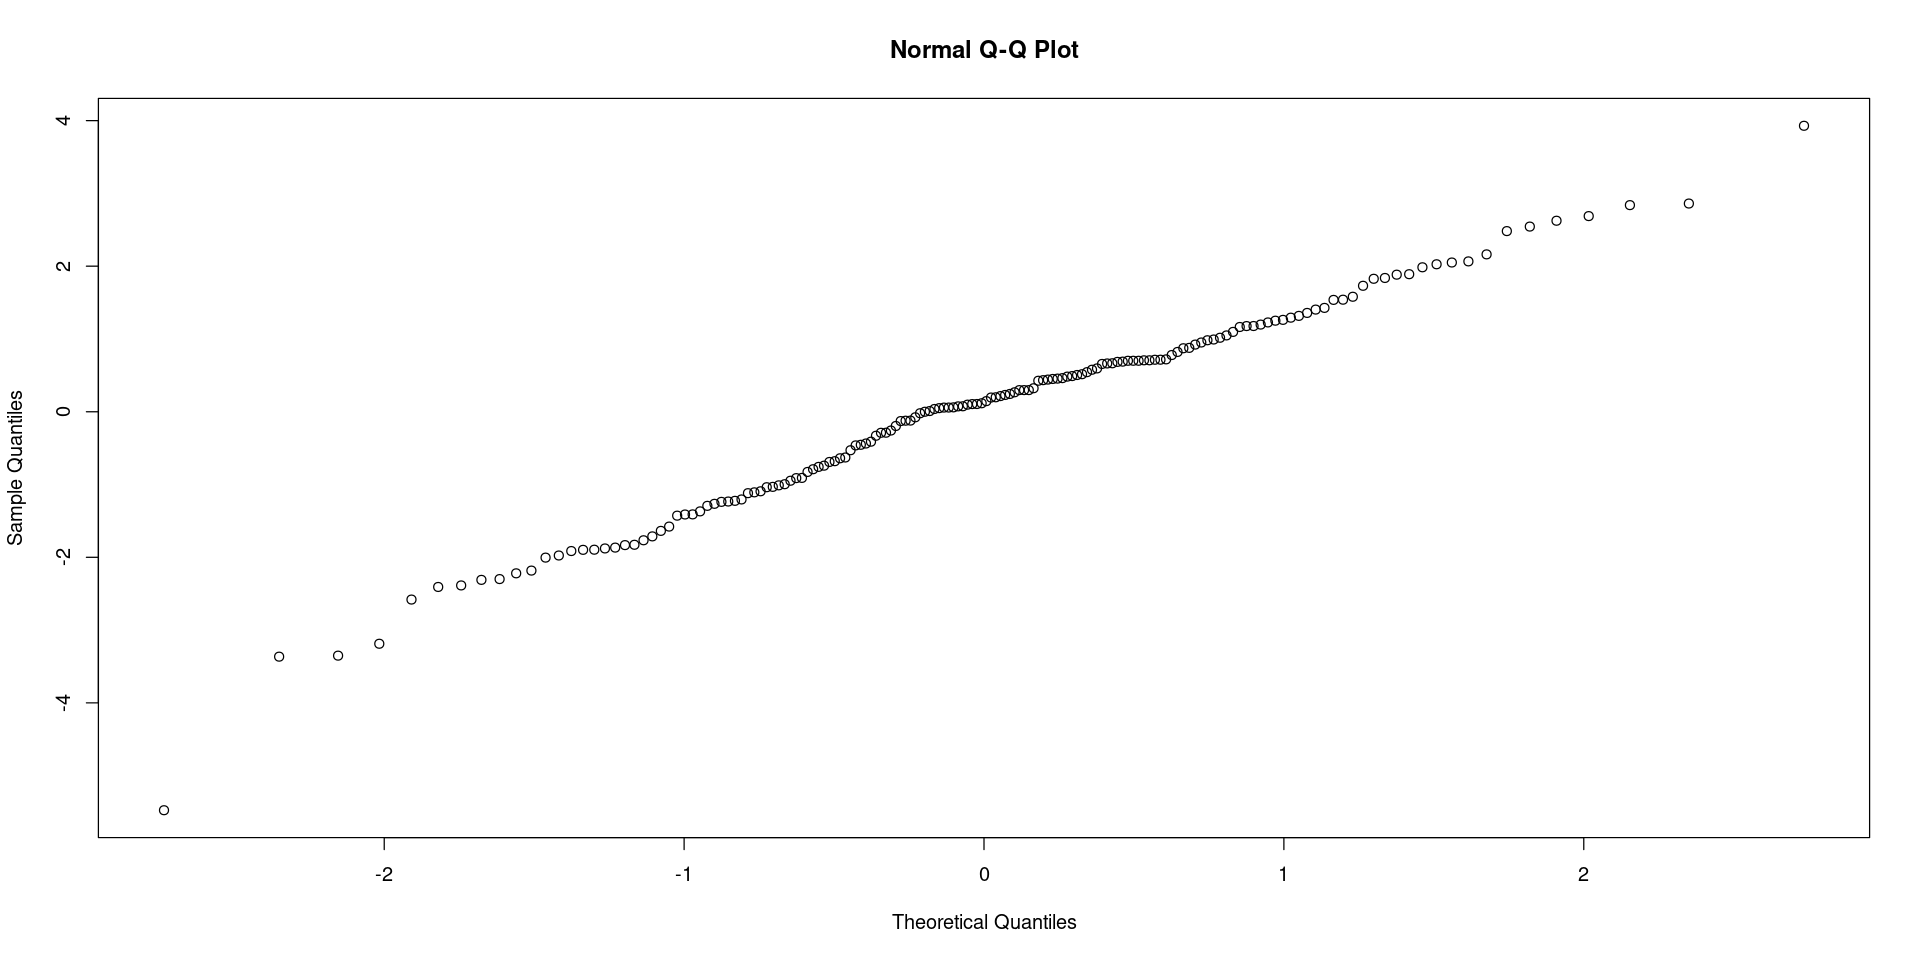

In [185]:
data_plot <- as.data.frame(qqnorm(model$residuals))

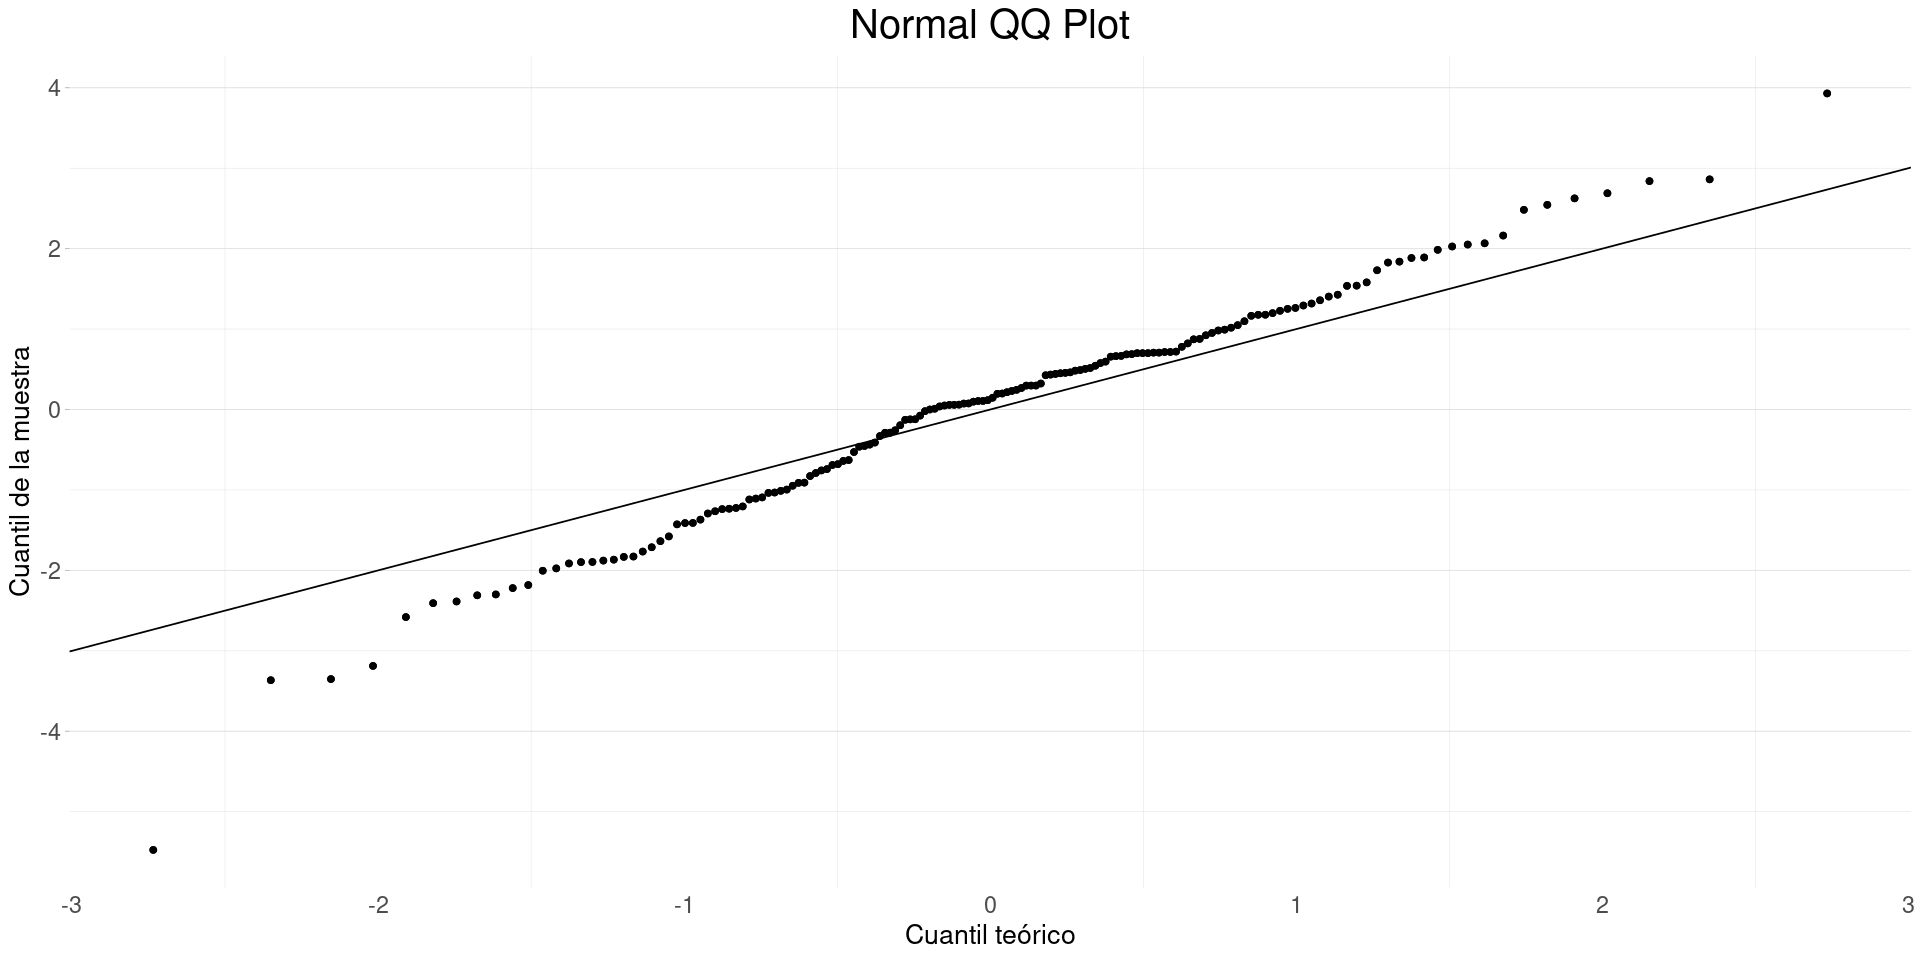

In [191]:

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0) +
    ggtitle("Normal QQ Plot") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    xlab("Cuantil teórico") + ylab("Cuantil de la muestra")

In [ ]:
n = nrow(PCA_DF)
indices = obtener_indices_kfold(n, n)

errores = data.frame(
    y   = double(),
    err = double()
)
for(i in sort(as.integer(indices))){
    train_df <- PCA_DF[-i,]
    test_df <- PCA_DF[i,]
    
    model <- lm(Y ~ ., data = train_df)
    Y_pred = predict(model, test_df)
    errores = rbind(errores, list(Y_pred, test_df$Y - Y_pred))
}
colnames(errores) <- c("y", "err")
err <- mean(errores$err^2)
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

### Árbol de regresión

In [ ]:
library(rpart)
library(rpart.plot)

In [ ]:
setSeed()

n = nrow(PCA_DF)
k = n

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP    =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- PCA_X

minsplits <- c(2, 5, 10, 15, 20, 25)

for (minsplit in minsplits) {
    for (maxdepth in c(4, 5, 6, 7, 8)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo2 <- rpart(Y ~ ., data = PCA_DF, control=parametros)

In [ ]:
rpart.plot(modelo2, digits=4)
title("Modelo 2")

In [ ]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- PCA_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

### KNN

In [ ]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

In [ ]:
setSeed()

n = nrow(TRAIN_X)
k = n

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- PCA_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
escalador = escaladores[[mejores_parametros$Escalador]]
X_scaled <- escalador$fit_transform(PCA_X)

wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
modelo3 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_scaled, TRAIN_Y)

### Regresión no paramétrica

In [ ]:
D <- function(x, y) ( sum( abs(x-y) ) )
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [ ]:
setSeed()

n = nrow(PCA_X)
k = n

indices = obtener_indices_kfold(n, k)
X <- PCA_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = MMScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

## PCA 2

In [193]:
PCA_DF <- PCA_DF[c(1,2, 7)]
PCA_X  <- PCA_DF[c(1,2)]

ERROR: Error in `[.data.frame`(PCA_DF, c(1, 2, 7)): undefined columns selected


### Regresión lineal

In [16]:
library("plot3D")

In [198]:
model <- lm(Y~., data=PCA_DF)

In [200]:
a <- summary(model)

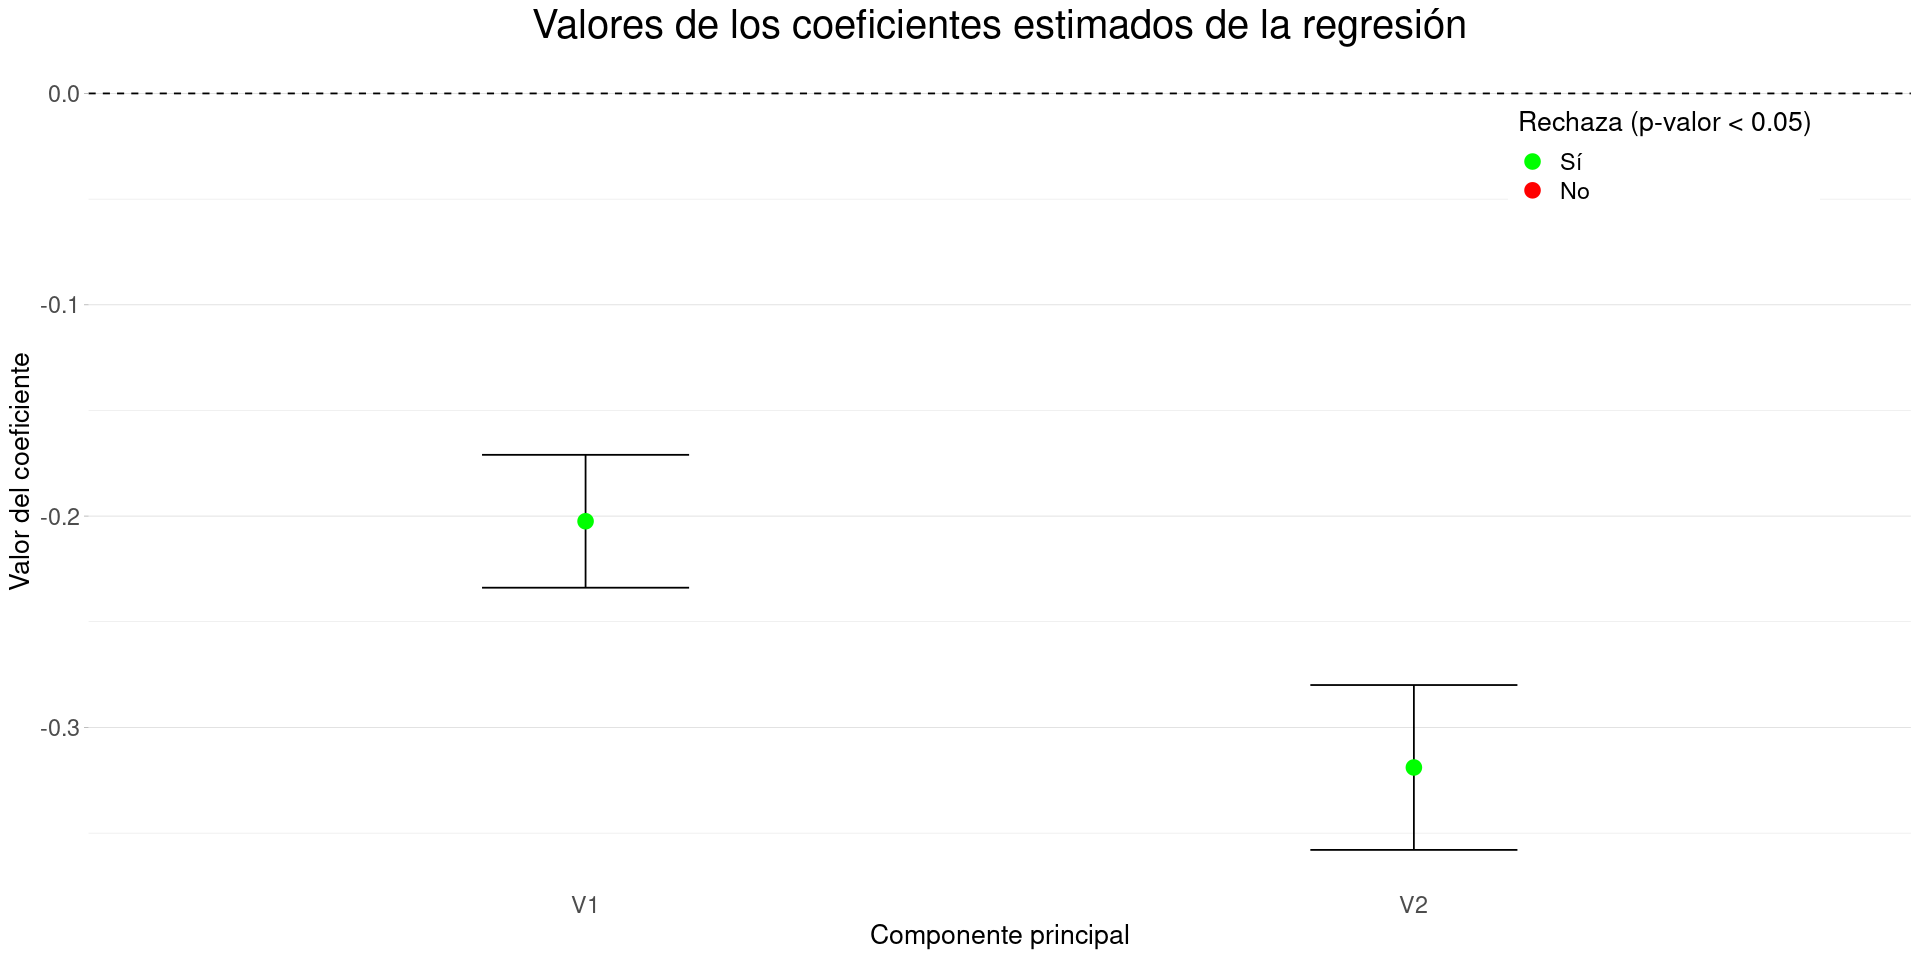

In [202]:
data_plot <- data.frame(
    x=colnames(PCA_X),
    y=a$coefficients[-1, 1],
    sd=a$coefficients[-1, 2],
    col=(a$coefficients[-1, 4] < 0.05)
)
colnames(data_plot) <- c("V", "Estimate", "SD", "Rechaza")

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x = V, y = Estimate)) + 
  ggtitle("Valores de los coeficientes estimados de la regresión") +
  geom_errorbar(aes(ymin = Estimate - 2*SD, ymax = Estimate + 2*SD),  width=0.25) +
  geom_point(aes(color = Rechaza), size = 4) + 
  theme_light() +
  scale_colour_manual(values = c("TRUE" = "green", "FALSE" = "red"),
                      labels = c("Sí", "No"), breaks = c("TRUE", "FALSE")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  geom_hline(yintercept=0, linetype="dashed") + 
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  xlab("Componente principal") + ylab("Valor del coeficiente")

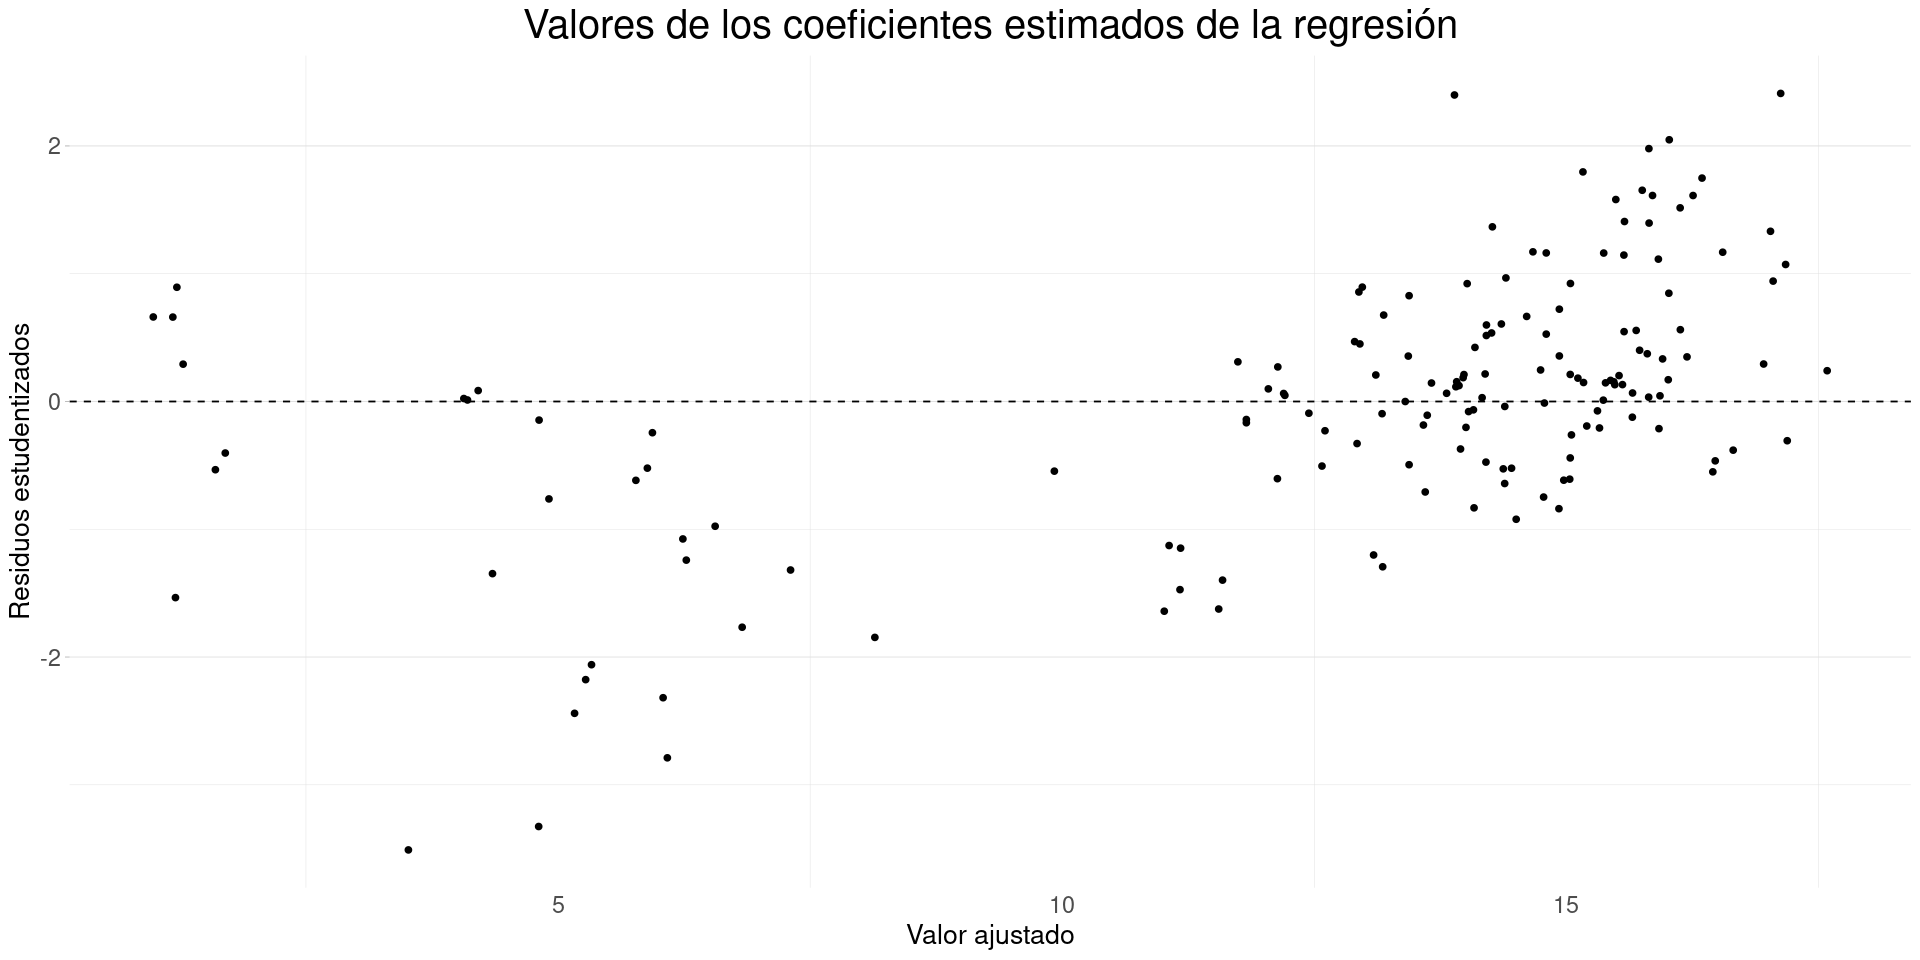

In [203]:
b <- data.frame(
    "y" = PCA_DF$Y,
    "tmenosi" = studres(model)
)
options(repr.plot.width=16, repr.plot.height=8)
ggplot(b, aes(x=y, y=tmenosi)) +
    ggtitle("Valores de los coeficientes estimados de la regresión") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    geom_hline(yintercept=0, linetype="dashed") + 
    xlab("Valor ajustado") + ylab("Residuos estudentizados")

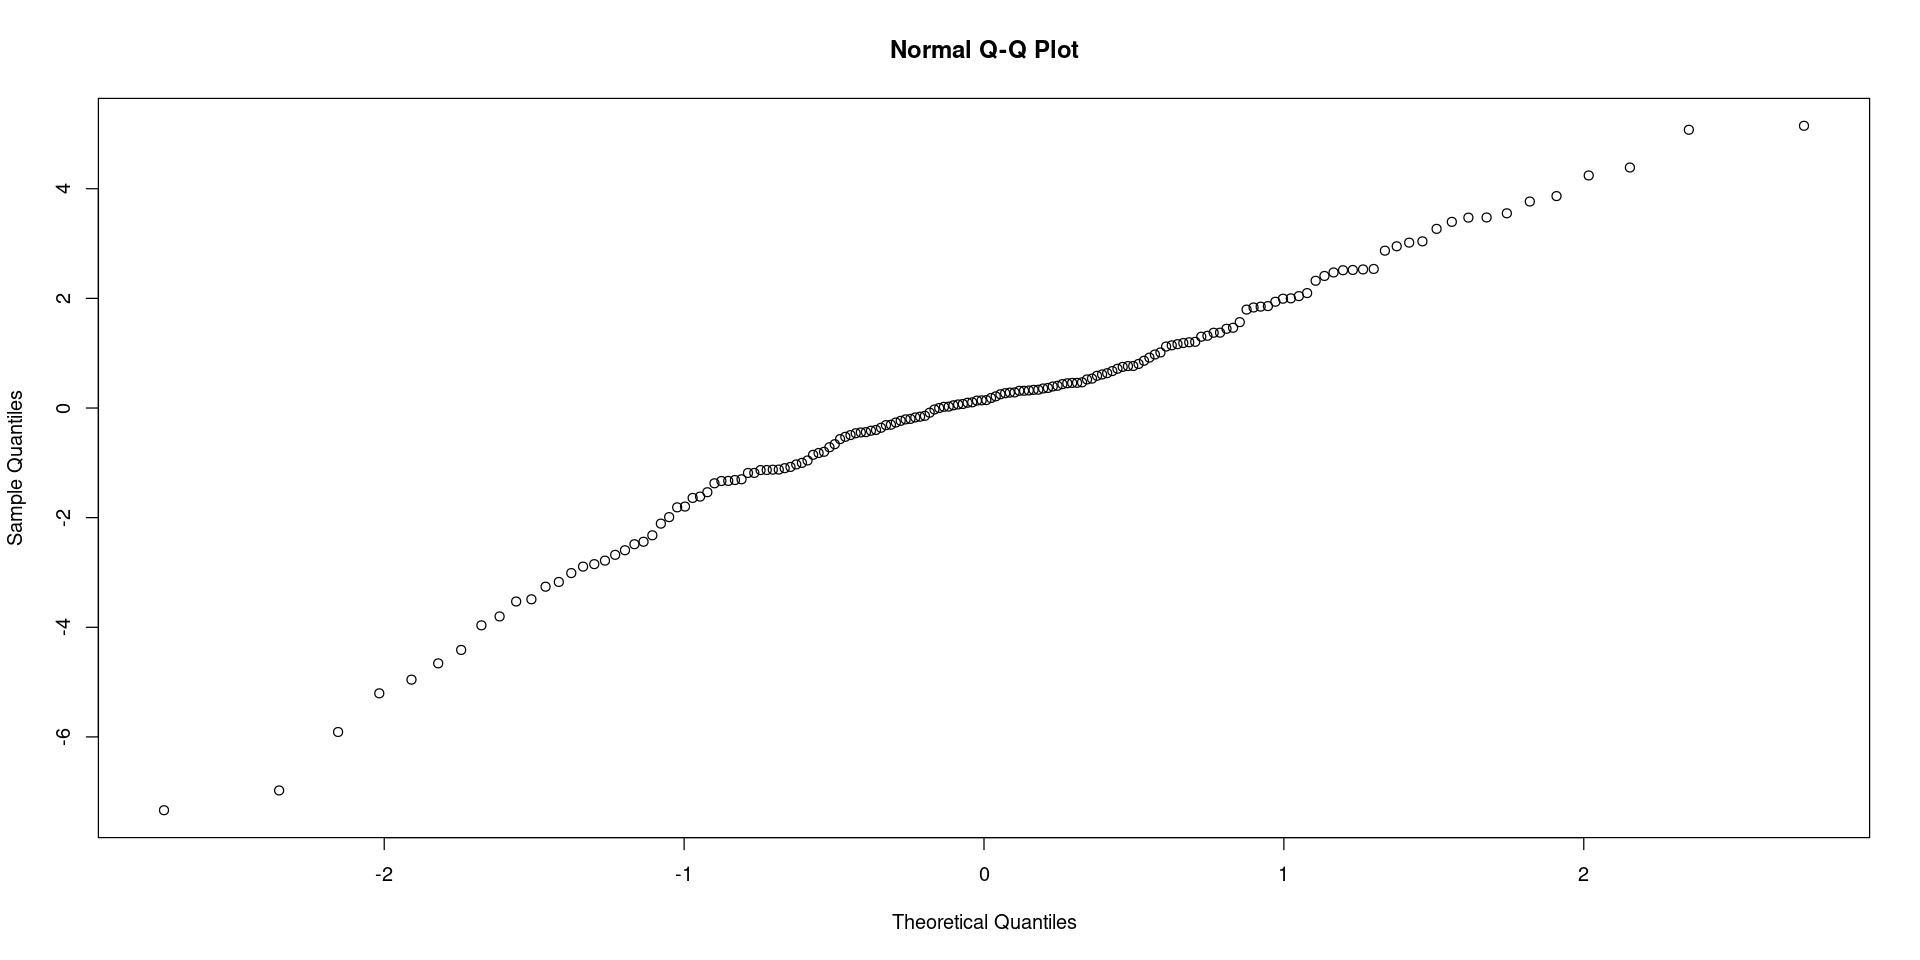

In [204]:
data_plot <- as.data.frame(qqnorm(model$residuals))

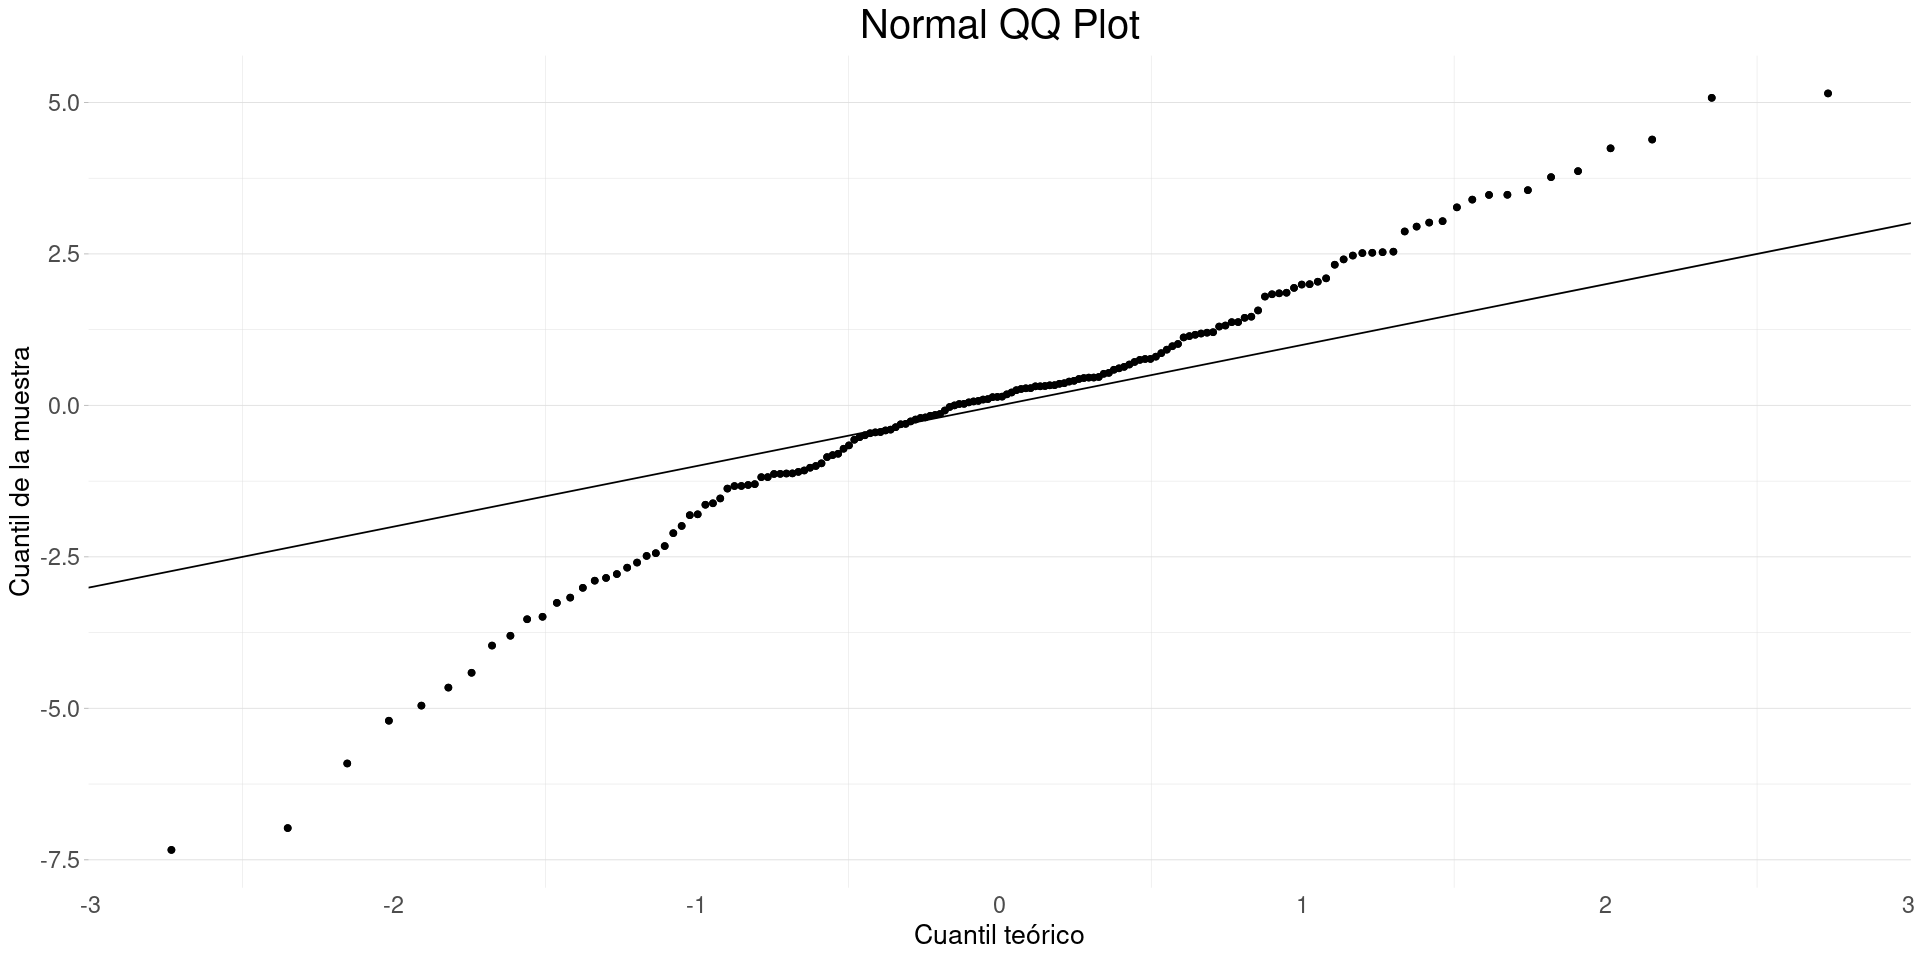

In [205]:

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0) +
    ggtitle("Normal QQ Plot") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    xlab("Cuantil teórico") + ylab("Cuantil de la muestra")

In [ ]:
n = nrow(PCA_DF)
indices = obtener_indices_kfold(n, n)
err = 0
for(i in indices){
    train_df <- PCA_DF[-i,]
    test_df <- PCA_DF[i,]
    
    model <- lm(Y ~ ., data = train_df)
    Y_pred = predict(model, test_df)
    err = err + sum((test_df$Y - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
reg <- function(x, y){
    return(12.6781-0.2024*x-0.3190*y)
}
grid.lines <- 30
x.pred <- seq(-30, 40, length = grid.lines)
y.pred <- seq(-20, 25, length = grid.lines)
z.pred <- matrix(reg(x.pred, y.pred), nrow = grid.lines, ncol = grid.lines)
x <- PCA_DF$V1
y <- PCA_DF$V2
z <- PCA_DF$Y
fitpoints <- predict(model)
scatter3D(x, y, z, colvar = NULL, col = "orange", pch = 20, cex = 2, theta = -5, phi = 0, ticktype = "detailed",
         surf = list(x = x.pred, y = y.pred, z = z.pred, col="black", alpha=0.3), bty = "b2",
         xlab = "CP1", ylab = "CP2", zlab = "Y")

In [ ]:
reg <- function(x, y){
    return(12.6781-0.2024*x-0.3190*y)
}
grid.lines <- 30
x.pred <- seq(-30, 40, length = grid.lines)
y.pred <- seq(-20, 25, length = grid.lines)
z.pred <- matrix(reg(x.pred, y.pred), nrow = grid.lines, ncol = grid.lines)
x <- PCA_DF$V1
y <- PCA_DF$V2
z <- PCA_DF$Y
fitpoints <- predict(model)
scatter3D(x, y, z,colvar = NULL, col = "orange", pch = 20, cex = 2, theta = 45, phi = 15, ticktype = "detailed",
         surf = list(x = x.pred, y = y.pred, z = z.pred, col="black", alpha=0.3),bty = "b2",
         xlab = "CP1", ylab = "CP2", zlab = "Y")

### Arbol de regresion

In [ ]:
library(parsnip)
library(rpart)
library(partykit)
library(parttree)

In [ ]:
setSeed()

n = nrow(PCA_DF)
k = 50

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP    =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- PCA_X

minsplits <- c(2, 3, 4, 5, 10, 15, 20, 25)

for (minsplit in minsplits) {
    for (maxdepth in c(1, 2, 3, 4)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)
colnames(PCA_DF) <- c("CP1", "CP2", "Y")
modelo2 <- rpart(Y ~ ., data = PCA_DF, control=parametros)

In [ ]:
rpart.plot(modelo2, digits=4)

In [ ]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- PCA_DF[, c(1,2)]
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
options(repr.plot.width=12, repr.plot.height=12)

ggplot(PCA_DF, aes(x=CP1, y=CP2)) +
    geom_point(aes(color=Y), size=2.5) +
    ggtitle("Partición del árbol de regresión") +
    geom_parttree(data = modelo2, aes(fill=Y), alpha = 0.6, flipaxes=TRUE) +
    theme_bw() +
    scale_color_gradient2(midpoint=8.5, low="blue", mid="white", high="red", aesthetics = c('colour', 'fill')) + 
    scale_y_continuous(breaks=seq(-20, 30, 2)) +
    scale_x_continuous(breaks=seq(-30, 40, 2)) +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.key.height = unit(5.5, 'cm'),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14))

### KNN

In [ ]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

In [ ]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- PCA_DF[, c(1,2)]
Y <- PCA_DF[, 'Y']
err = 0
for(i in indices){
    model <- knnr(n_neighbors=as.integer(1), p=2, weights="uniform")$fit(X[-i, ], Y[-i])
    Y_pred = as.double(model$predict(X[i, ]))
    err = err + sum((Y[i] - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
library(ggvoronoi)

In [ ]:
ggplot(PCA_DF, aes(V1, V2, fill = Y)) +
    geom_voronoi() +
    geom_point() +
    xlab("CP1") + ylab("CP2") + 
    ggtitle("Diagrama de Voronoi") +
    scale_color_gradient2(midpoint=8.5, low="blue", mid="white", high="red", aesthetics = c('colour', 'fill')) +
    theme_bw() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.key.height = unit(5, 'cm'),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14))

### Regresión no paramétrica

In [19]:
D <- function(x, y) ( sqrt ( sum( (x-y)^2 ) ) )
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [45]:
setSeed()

n = nrow(PCA_X)
k = n

indices = obtener_indices_kfold(n, k)
X <- PCA_DF[c(1,2)]

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = MMScaler()

hs = seq(0.01, 0.5, 0.005)
K = dnorm
for(h in hs){
    err = 0
    for(i in indices){
        X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
        Y_train = TRAIN_Y[-i]
        X_test_scaled = as.matrix(escalador$transform(X[i, ]))

        Y_test = TRAIN_Y[i]
        Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
        err = err + sum((Y_test - Y_pred)^2)
    }
    resultados = rbind(resultados, list(h, err/n))
    message(progreso(h, hs))
}


colnames(resultados)  <- c("h", "Error")

El progreso es del 1 %

El progreso es del 2 %

El progreso es del 3 %

El progreso es del 4 %

El progreso es del 5.1 %

El progreso es del 6.1 %

El progreso es del 7.1 %

El progreso es del 8.1 %

El progreso es del 9.1 %

El progreso es del 10.1 %

El progreso es del 11.1 %

El progreso es del 12.1 %

El progreso es del 13.1 %

El progreso es del 14.1 %

El progreso es del 15.2 %

El progreso es del 16.2 %

El progreso es del 17.2 %

El progreso es del 18.2 %

El progreso es del 19.2 %

El progreso es del 20.2 %

El progreso es del 21.2 %

El progreso es del 22.2 %

El progreso es del 23.2 %

El progreso es del 24.2 %

El progreso es del 25.3 %

El progreso es del 26.3 %

El progreso es del 27.3 %

El progreso es del 28.3 %

El progreso es del 29.3 %

El progreso es del 30.3 %

El progreso es del 31.3 %

El progreso es del 32.3 %

El progreso es del 33.3 %

El progreso es del 34.3 %

El progreso es del 35.4 %

El progreso es del 36.4 %

El progreso es del 37.4 %

El progreso es del

In [58]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,Error
,<dbl>,<dbl>
11,0.06,3.984847


In [64]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- PCA_DF[, c(1,2)]
escalador = MMScaler()
K = dnorm
h = mejores_parametros$h
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  3.98484683811432"


In [65]:
library("plot3D")

In [90]:
D <- function(x, y) ( sqrt ( sum( (x-y)^2 ) ) )
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    if(sum(wis)==0){
        return(mean(Y))
    }
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [169]:
mejores_parametros$h

[1] 0.06

In [128]:
escalador = MMScaler()
X <- as.matrix(escalador$fit_transform(PCA_DF[, c(1,2)]))
Y <- PCA_DF[, 3]
h <- mejores_parametros$h
K <- dnorm
f <- function(x0) (npr(x0, X, Y, h, K))

grid.lines <- 100
x.pred <- seq(0, 1, length = grid.lines)
y.pred <- seq(0, 1, length = grid.lines)
z.pred <- matrix(f(expand.grid(x.pred, y.pred)),
                 nrow = grid.lines, ncol = grid.lines)
x <- X[, 1]
y <- X[, 2]
z <- Y

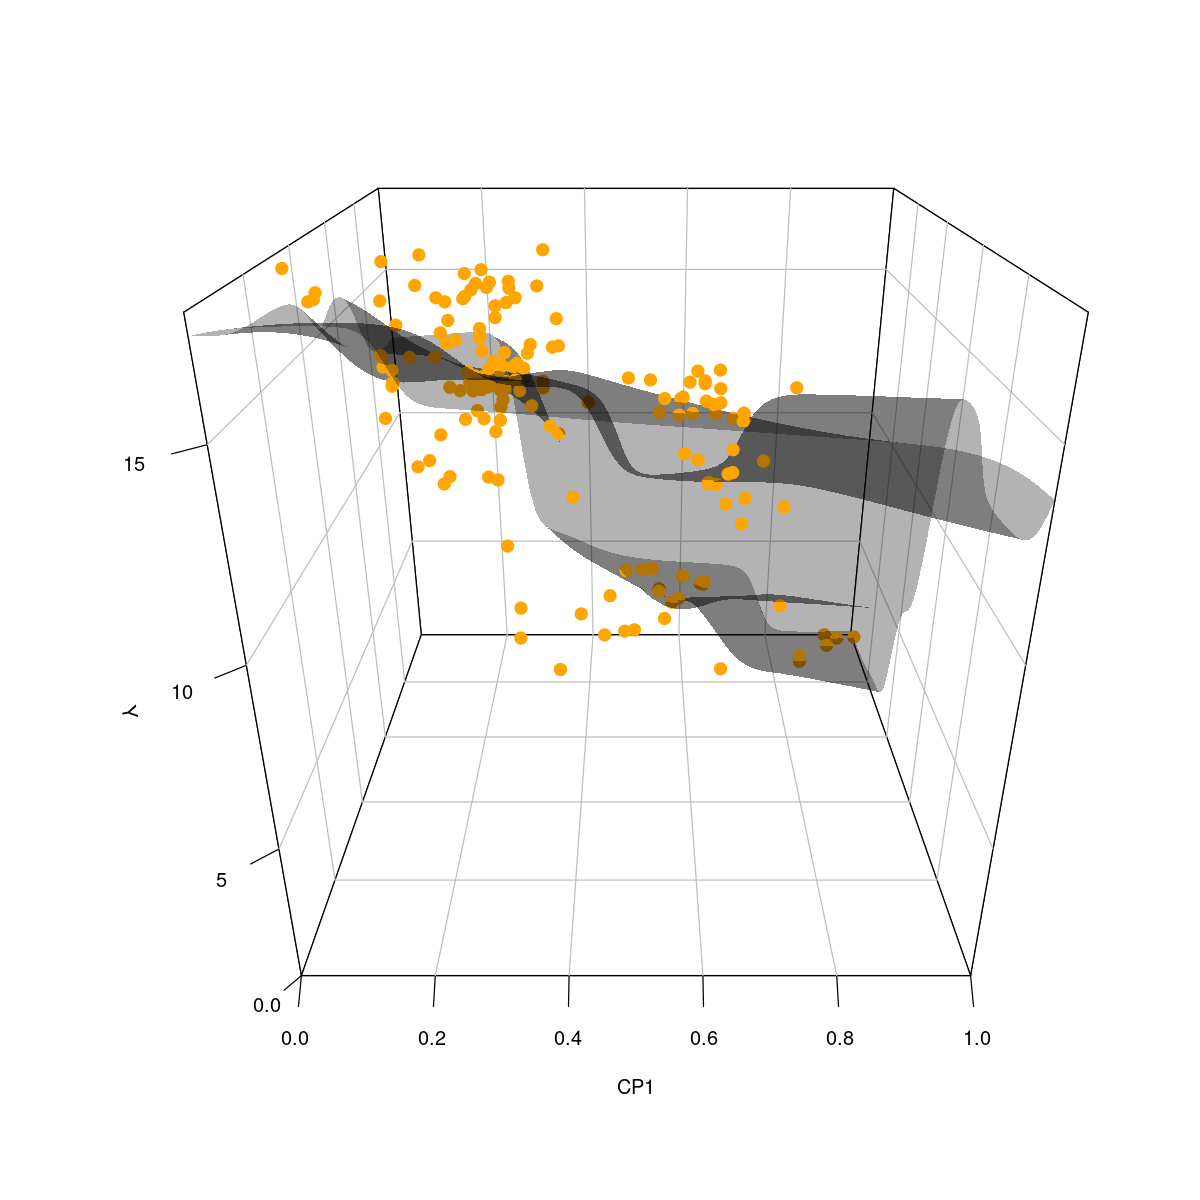

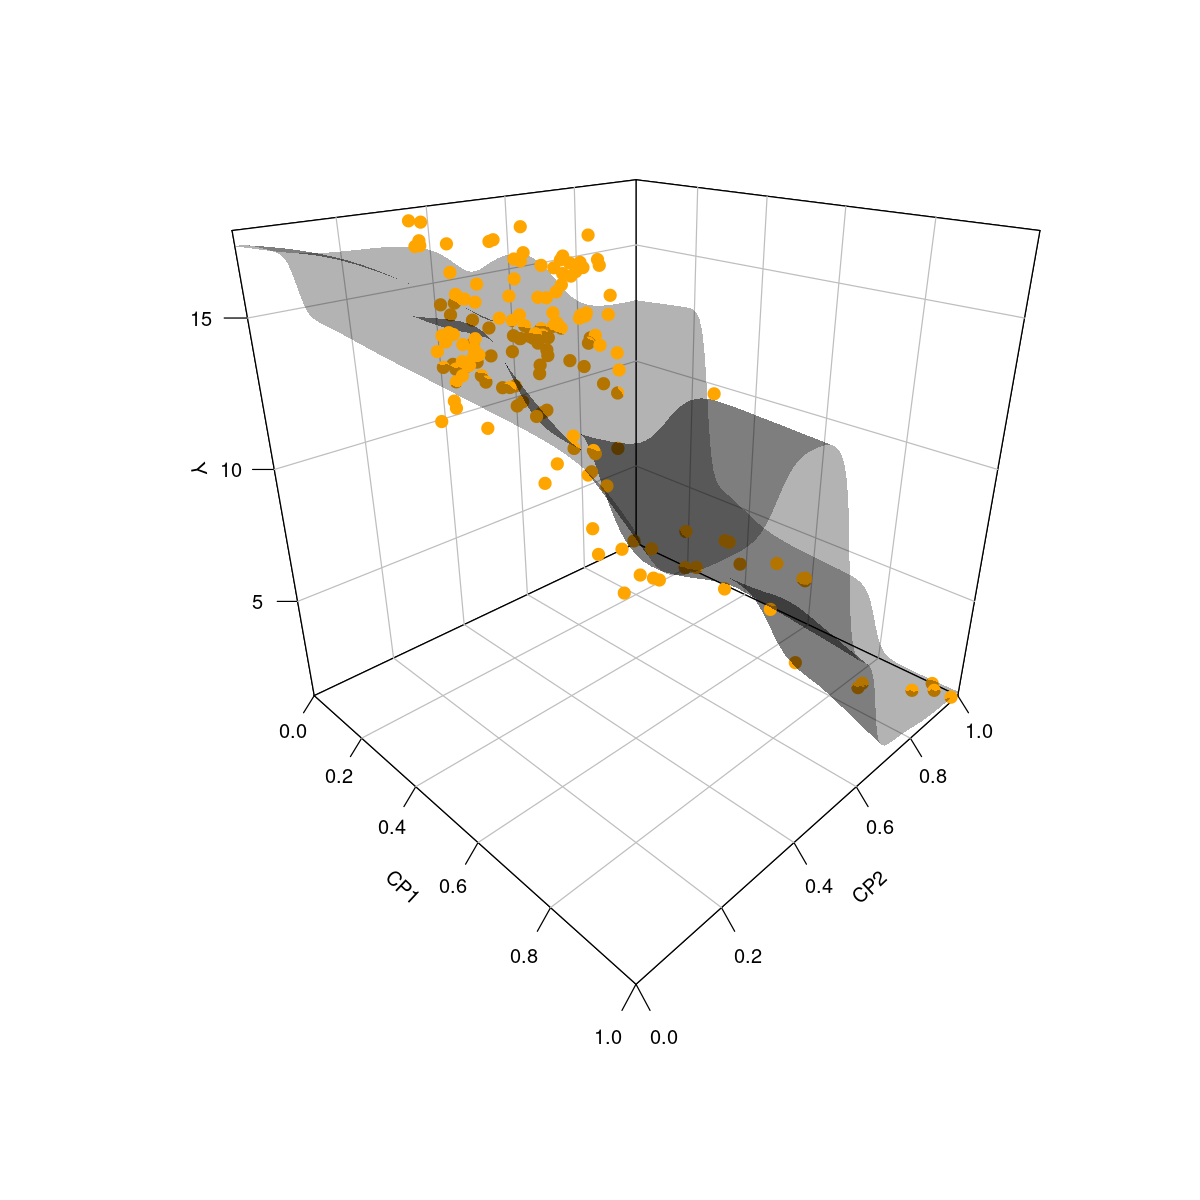

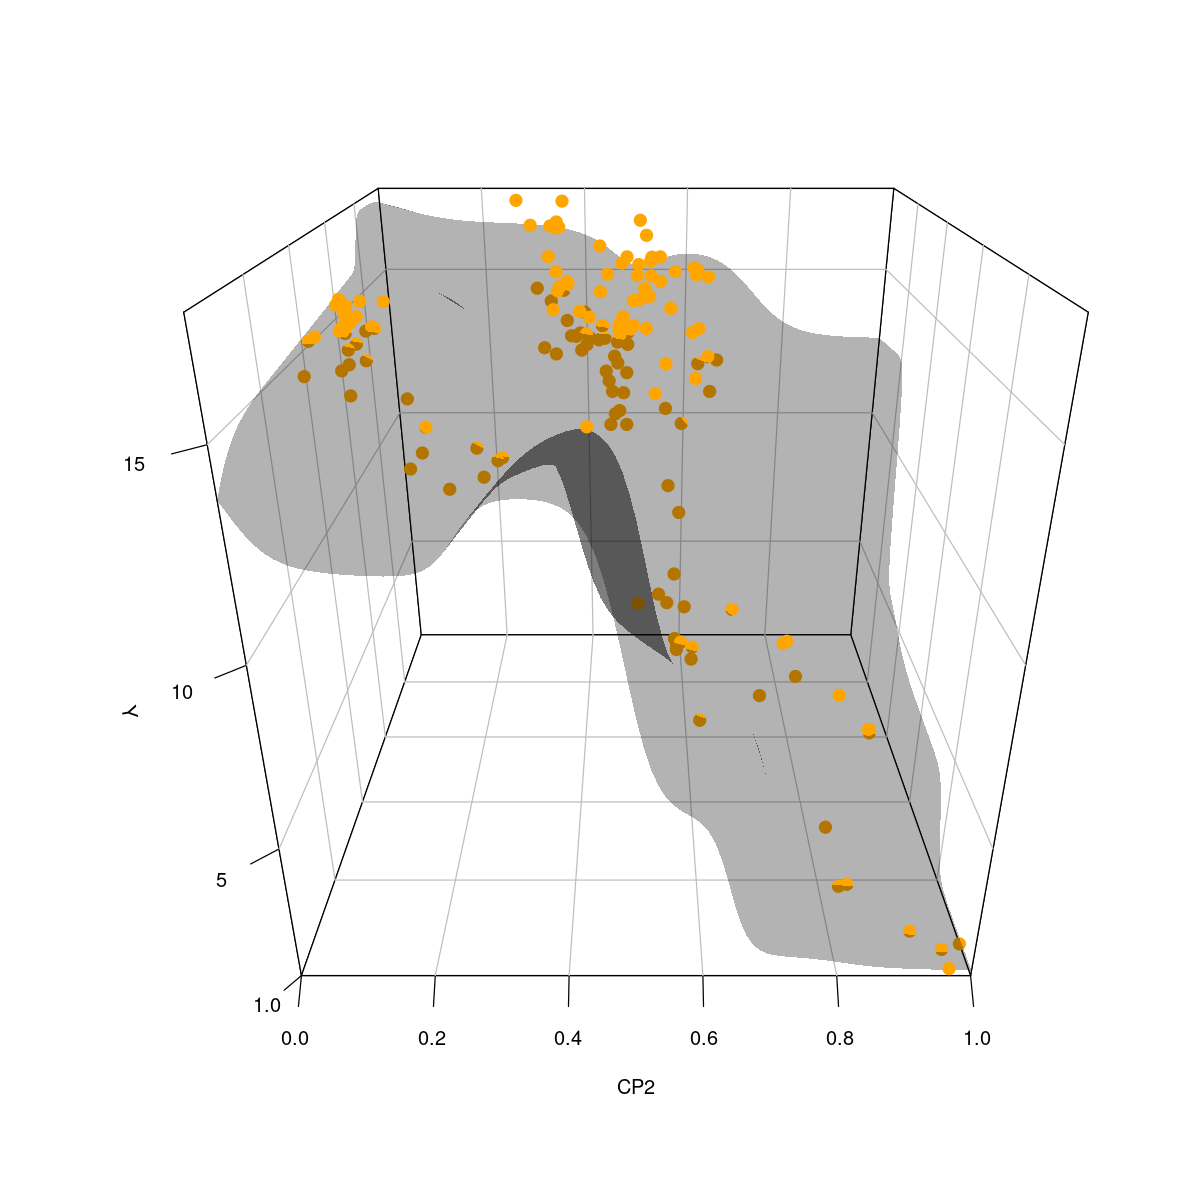

In [168]:
options(repr.plot.width=10, repr.plot.height=10)

scatter3D(x, y, z, colvar = NULL, col = "orange", pch = 20, cex = 2, theta = 0, phi = 25, ticktype = "detailed",
         surf = list(x = x.pred, y = y.pred, z = z.pred, col="black", alpha=0.3), bty = "b2",
         xlab = "CP1", ylab = "CP2", zlab = "Y")
scatter3D(x, y, z, colvar = NULL, col = "orange", pch = 20, cex = 2, theta = 45, phi = 25, ticktype = "detailed",
         surf = list(x = x.pred, y = y.pred, z = z.pred, col="black", alpha=0.3), bty = "b2",
         xlab = "CP1", ylab = "CP2", zlab = "Y")
scatter3D(x, y, z, colvar = NULL, col = "orange", pch = 20, cex = 2, theta = 90, phi = 25, ticktype = "detailed",
         surf = list(x = x.pred, y = y.pred, z = z.pred, col="black", alpha=0.3), bty = "b2",
         xlab = "CP1", ylab = "CP2", zlab = "Y")